=== RESULTADOS DEL MODELO ===
Pendiente (<U+03B2><U+2081>): 4.429 gramos por libra adicional de peso materno
Coeficiente de determinaci<U+00F3>n (R<U+00B2>): 0.0345 (3.45% de la varianza explicada)

[1] "=== GRAFICOS DE DIAGNOSTICO ===\n"

Call:
lm(formula = bwt ~ lwt, data = birthwt)

Residuals:
     Min       1Q   Median       3Q      Max 
-2192.12  -497.97    -3.84   508.32  2075.60 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 2369.624    228.493  10.371   <2e-16 ***
lwt            4.429      1.713   2.585   0.0105 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 718.4 on 187 degrees of freedom
Multiple R-squared:  0.0345,	Adjusted R-squared:  0.02933 
F-statistic: 6.681 on 1 and 187 DF,  p-value: 0.0105

[1] "=== DIAGNOSTICOS DEL MODELO ===\n"


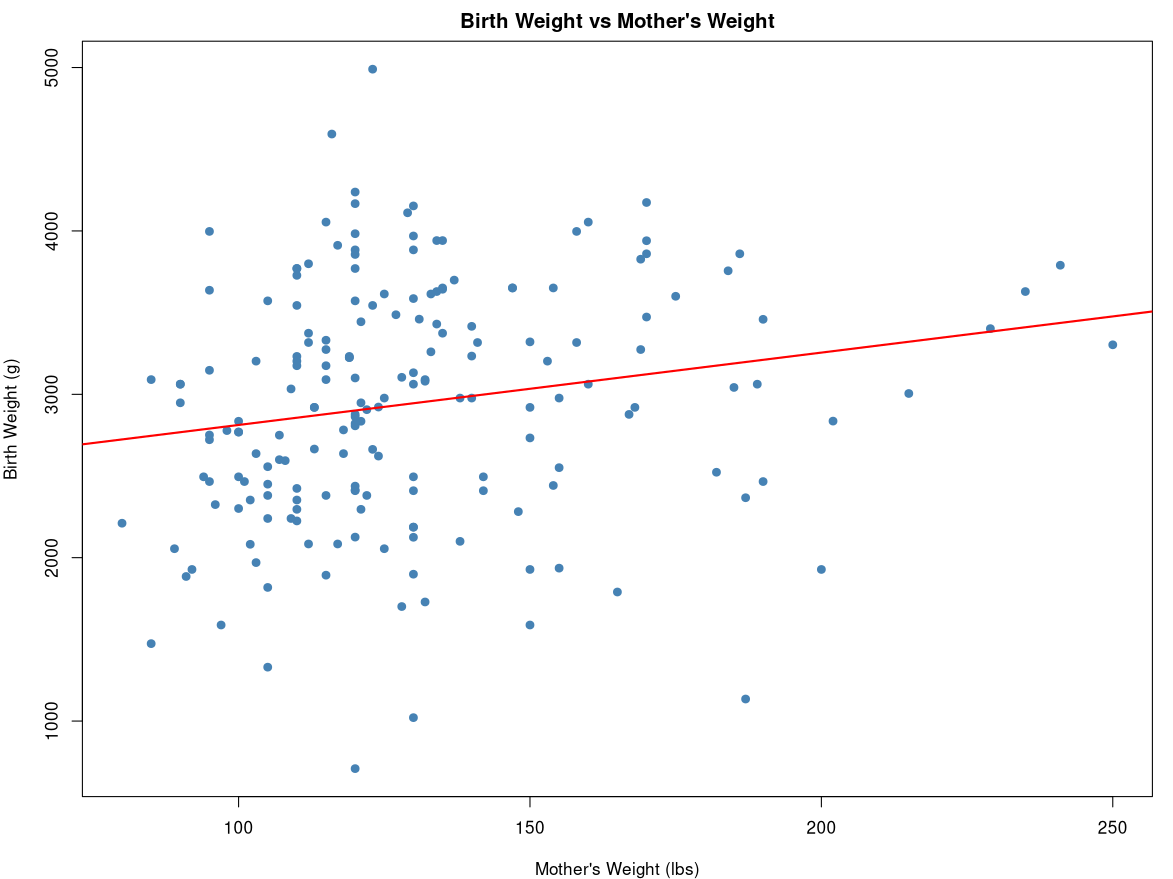

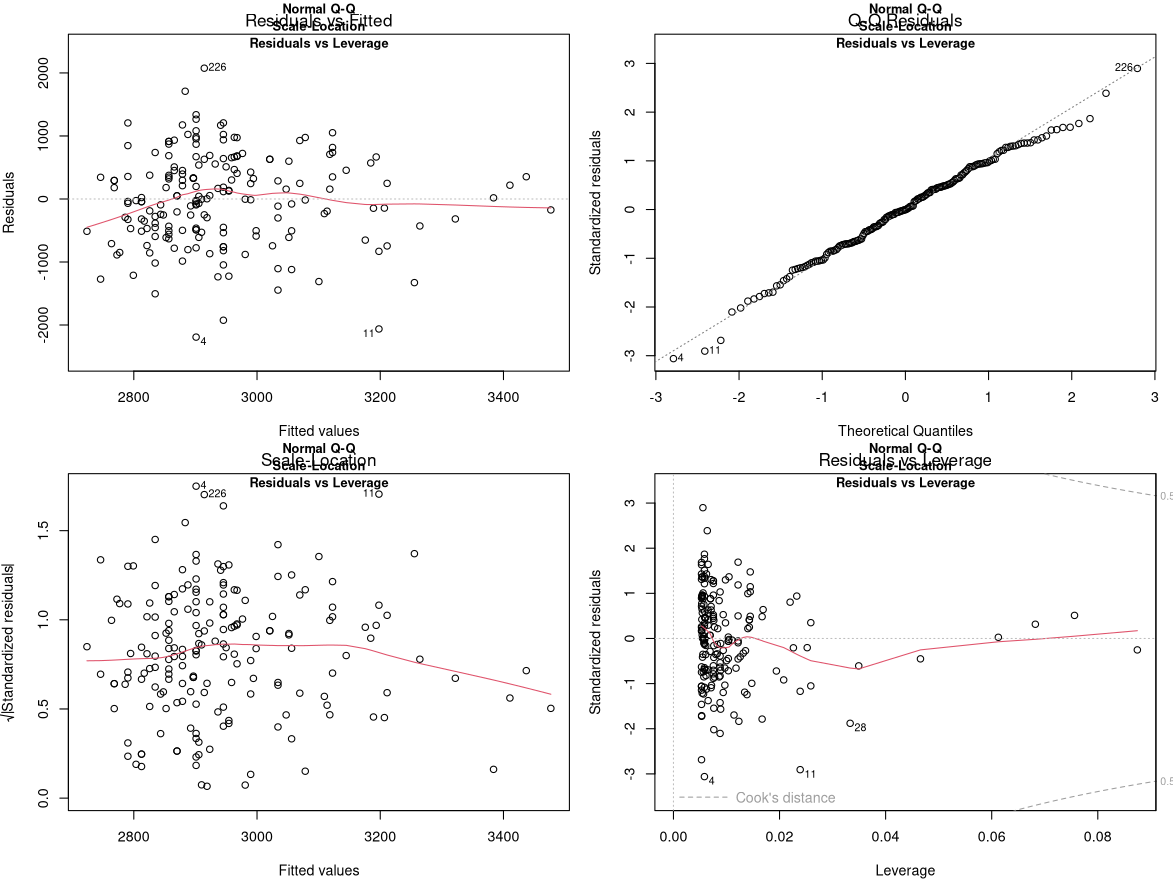

[1] "=== PRUEBAS ESTADISTICAS ===\n"
[1] "1. Prueba de heteroscedasticidad (Breusch-Pagan)"

	studentized Breusch-Pagan test

data:  modelo
BP = 0.048718, df = 1, p-value = 0.8253

[1] "2. Prueba de normalidad de residuos (Shapiro-Wilk)"

	Shapiro-Wilk normality test

data:  residuals(modelo)
W = 0.99312, p-value = 0.5215

[1] "3. Prueba de autocorrelaci<U+00F3>n de residuos (Durbin-Watson)"

	Durbin-Watson test

data:  modelo
DW = 0.26463, p-value < 2.2e-16
alternative hypothesis: true autocorrelation is greater than 0

[1] "4. Prueba de multicolinealidad"
          lwt       bwt
lwt 1.0000000 0.1857333
bwt 0.1857333 1.0000000


In [ ]:
# 1. Cargar librería y dataset
library(MASS)
data(birthwt)

# 2. Ajustar modelo OLS: Peso neonatal (bwt) ~ Peso materno (lwt)
modelo <- lm(bwt ~ lwt, data = birthwt)

# 3. Extraer métricas principales
resumen <- summary(modelo)
pendiente <- coef(modelo)["lwt"]
r2      <- resumen$r.squared

cat("=== RESULTADOS DEL MODELO ===")
cat(sprintf("Pendiente (β₁): %.3f gramos por libra adicional de peso materno\n", pendiente))
cat(sprintf("Coeficiente de determinación (R²): %.4f (%.2f%% de la varianza explicada)\n\n", r2, r2*100))

# 4. Configurar área gráfica 2x2 y generar diagnósticos
print("=== GRAFICOS DE DIAGNOSTICO ===\n")
par(mfrow = c(2, 2), mar = c(4, 4, 2, 1))

# Restaurar parámetros gráficos
par(mfrow = c(1, 1))

# MUESTRA el resumen del modelo con p-values e intervalos de confianza
print(summary(modelo))

# Plot the data with the fitted regression line
plot(birthwt$lwt, birthwt$bwt, main = "Birth Weight vs Mother's Weight", 
     xlab = "Mother's Weight (lbs)", ylab = "Birth Weight (g)", pch = 19, col = "steelblue")
abline(modelo, col = "red", lwd = 2)

print("=== DIAGNOSTICOS DEL MODELO ===\n")
# Check regression assumptions with diagnostic plots
par(mfrow = c(2, 2))
plot(modelo, 
     main = c("Residuos vs Ajustados", "Normal Q-Q", 
              "Scale-Location", "Residuals vs Leverage"),
     cex.main = 0.9)
par(mfrow = c(1, 1))


print("=== PRUEBAS ESTADISTICAS ===\n")
print("1. Prueba de heteroscedasticidad (Breusch-Pagan)")
# Breusch-Pagan test for heteroscedasticity
library(lmtest)
print(bptest(modelo))

print("2. Prueba de normalidad de residuos (Shapiro-Wilk)")
# Shapiro-Wilk test for normality of residuals
print(shapiro.test(residuals(modelo)))

print("3. Prueba de autocorrelación de residuos (Durbin-Watson)")
# Durbin-Watson test for autocorrelation
print(dwtest(modelo))

print("4. Prueba de multicolinealidad")
# Check for multicollinearity among predictors
print(cor(birthwt[, c("lwt", "bwt")]))